# CPU Scheduling Algorithm Comparison Using Google Borg Cluster Traces

**Authors:** Md. Bin Monjur Azmine, Md. Mashrafi, Md. Ashraful Islam Shimanto, Md. Rubayet Tasnim and [Md. Shymon Islam](https://scholar.google.com/citations?user=QuHVGA4AAAAJ&hl=en&oi=ao)  
**Institution:** [Shahjalal University of Science and Technology](https://www.sust.edu/)  
**Research Context:** Operating Systems  
**Dataset:** [Google 2019 Cluster Sample — Borg Traces (Kaggle)](https://www.kaggle.com/datasets/derrickmwiti/google-2019-cluster-sample)

---

## Abstract

This notebook implements and evaluates eight classical and modern CPU scheduling algorithms on real-world workload data extracted from Google's Borg cluster traces (2019). The algorithms studied are **First Come First Served (FCFS)**, **Shortest Job First (SJF)**, **Round Robin (RR)**, **Priority Scheduling**, **Multilevel Queue (MLQ)**, **Multi-Level Feedback Queue (MLFQ)**, **Earliest Deadline First (EDF)**, and the Linux **Completely Fair Scheduler (CFS)**. Each algorithm is simulated on a preprocessed 500-job sample drawn from production cluster workloads. Performance is evaluated across six metrics: average waiting time, average turnaround time, average response time, throughput, Jain's fairness index, and context switch count.

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Dataset](#2-dataset)
   - [2.1 Data Loading](#21-data-loading)
   - [2.2 Data Preprocessing](#22-data-preprocessing)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Feature Engineering — Synthetic Deadlines](#4-feature-engineering--synthetic-deadlines)
5. [Simulation Setup](#5-simulation-setup)
6. [CPU Scheduling Algorithm Implementations](#6-cpu-scheduling-algorithm-implementations)
   - [6.1 Metric Helper Functions](#61-metric-helper-functions)
   - [6.2 First Come First Served (FCFS)](#62-first-come-first-served-fcfs)
   - [6.3 Shortest Job First (SJF)](#63-shortest-job-first-sjf)
   - [6.4 Round Robin (RR)](#64-round-robin-rr)
   - [6.5 Priority Scheduling](#65-priority-scheduling)
   - [6.6 Multilevel Queue (MLQ)](#66-multilevel-queue-mlq)
   - [6.7 Multi-Level Feedback Queue (MLFQ)](#67-multi-level-feedback-queue-mlfq)
   - [6.8 Earliest Deadline First (EDF)](#68-earliest-deadline-first-edf)
   - [6.9 Completely Fair Scheduler (CFS)](#69-completely-fair-scheduler-cfs)
7. [Results & Comparison](#7-results--comparison)
8. [Performance Visualization](#8-performance-visualization)

---

## 1. Environment Setup

All required libraries are imported here. This notebook is designed to run on **Kaggle** (Python 3 kernel) or any standard Python 3.8+ environment with `numpy`, `pandas`, and `matplotlib` installed.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import heapq
import ast
import os

# List available input files (Kaggle environment)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/derrickmwiti/google-2019-cluster-sample/borg_traces_data.csv


---

## 2. Dataset

### 2.1 Data Loading

The dataset is the **Google Borg Cluster Traces (2019)**, a sample of scheduling events from Google's internal cluster management system, Borg. Each row represents a task instance with metadata including start/end times, CPU usage, scheduling priority, and machine assignment.

In [6]:
main_data = pd.read_csv(
    "/kaggle/input/datasets/derrickmwiti/google-2019-cluster-sample/borg_traces_data.csv"
)

print(f"Dataset shape: {main_data.shape}")
print(f"\nColumns:\n{main_data.columns.tolist()}")
main_data.head()

Dataset shape: (405894, 34)

Columns:
['Unnamed: 0', 'time', 'instance_events_type', 'collection_id', 'scheduling_class', 'collection_type', 'priority', 'alloc_collection_id', 'instance_index', 'machine_id', 'resource_request', 'constraint', 'collections_events_type', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster', 'event', 'failed']


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


### 2.2 Data Preprocessing

The raw dataset contains many columns irrelevant to scheduling simulation. This section:

1. **Drops** administrative and distribution columns not needed for the scheduler.
2. **Selects** the core scheduling-relevant features: instance index, arrival/finish times, priority, and CPU usage.
3. **Filters out** failed jobs (`failed == 0`) and invalid time windows (`end_time > start_time`).
4. **Renames** columns to more intuitive simulation-friendly names.

In [7]:
# Columns to remove — not relevant to scheduling simulation
DROP_COLS = [
    'Unnamed: 0',
    'collection_name',
    'collection_logical_name',
    'constraint',
    'start_after_collection_ids',
    'cpu_usage_distribution',
    'tail_cpu_usage_distribution',
]

df = main_data.drop(columns=DROP_COLS, errors='ignore')

# Select scheduling-relevant features
df = df[[
    'instance_index',
    'start_time',
    'end_time',
    'priority',
    'average_usage',
    'maximum_usage',
    'machine_id',
    'scheduling_class',
    'event',
    'failed',
]]

# Remove rows with missing critical fields
df = df.dropna(subset=['instance_index', 'start_time', 'end_time', 'average_usage'])

# Keep only successfully completed jobs and valid time windows
df = df[df['failed'] == 0]
df = df[df['end_time'] > df['start_time']]

# Rename to simulation-friendly names
df = df.rename(columns={
    'instance_index': 'PID',
    'start_time':     'Arrival_Time',
    'end_time':       'Finish_Time',
    'priority':       'Priority',
    'average_usage':  'CPU_Usage',
})

print(f"Rows after cleaning: {len(df):,}")
df.head()

Rows after cleaning: 313,216


,PID,Arrival_Time,Finish_Time,Priority,CPU_Usage,maximum_usage,machine_id,scheduling_class,event,failed
2,376,81300000000,81600000000,103,"{'cpus': 0.024200439453125, 'memory': 0.002788...","{'cpus': 0.06005859375, 'memory': 0.0028457641...",169321752432,2,SCHEDULE,0
4,3907,1565315000000,1565317000000,0,"{'cpus': 0.000270843505859375, 'memory': 7.629...","{'cpus': 0.00041484832763671875, 'memory': 7.6...",231364893292,2,FINISH,0
5,345,1626600000000,1626761000000,103,"{'cpus': 0.0794677734375, 'memory': 0.00323486...","{'cpus': 0.21923828125, 'memory': 0.0040512084...",34202965855,0,SCHEDULE,0
6,13138,343800000000,344100000000,117,"{'cpus': 0.0042572021484375, 'memory': 0.00131...","{'cpus': 0.012481689453125, 'memory': 0.001653...",10129440520,1,ENABLE,0
7,393,455400000000,455700000000,103,"{'cpus': 0.0064697265625, 'memory': 0.00075817...","{'cpus': 0.027984619140625, 'memory': 0.000782...",447672988,2,FINISH,0


#### CPU Usage Parsing and Burst Time Derivation

The `CPU_Usage` column stores usage data as a serialised dictionary string (e.g., `"{'cpus': 0.12, 'memory': ...}"`). We extract the `cpus` field and convert it to an integer **burst time** — a proxy for the CPU time each job requires.

$$\text{Burst\_Time}_i = \lfloor \text{CPU\_Usage}_i \times 100 \rfloor + 1$$

The `+1` guarantees every job has at least 1 tick of burst time.

In [8]:
# Parse CPU fraction from nested string-dict format
df['CPU_Usage'] = df['CPU_Usage'].apply(
    lambda x: ast.literal_eval(x)['cpus'] if isinstance(x, str) else np.nan
)

# Drop rows where parsing failed
df = df.dropna(subset=['CPU_Usage'])

# Derive burst time: scale CPU fraction → integer tick count (+1 avoids zero burst)
df['Burst_Time'] = (df['CPU_Usage'] * 100).astype(int) + 1

df = df.reset_index(drop=True)

print(f"Total valid jobs: {len(df):,}")
print(f"\nBurst Time summary:\n{df['Burst_Time'].describe().round(2)}")
df.head()

Total valid jobs: 313,216

Burst Time summary:
count    313216.00
mean          1.51
std           1.89
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          54.00
Name: Burst_Time, dtype: float64


,PID,Arrival_Time,Finish_Time,Priority,CPU_Usage,maximum_usage,machine_id,scheduling_class,event,failed,Burst_Time
0,376,81300000000,81600000000,103,0.024200,"{'cpus': 0.06005859375, 'memory': 0.0028457641...",169321752432,2,SCHEDULE,0,3
1,3907,1565315000000,1565317000000,0,0.000271,"{'cpus': 0.00041484832763671875, 'memory': 7.6...",231364893292,2,FINISH,0,1
2,345,1626600000000,1626761000000,103,0.079468,"{'cpus': 0.21923828125, 'memory': 0.0040512084...",34202965855,0,SCHEDULE,0,8
3,13138,343800000000,344100000000,117,0.004257,"{'cpus': 0.012481689453125, 'memory': 0.001653...",10129440520,1,ENABLE,0,1
4,393,455400000000,455700000000,103,0.006470,"{'cpus': 0.027984619140625, 'memory': 0.000782...",447672988,2,FINISH,0,1


---

## 3. Exploratory Data Analysis (EDA)

Before simulation we examine the distribution of key scheduling attributes to understand workload characteristics.

In [9]:
print(f"Total jobs         : {len(df):,}")
print(f"Arrival Time range : {df['Arrival_Time'].min():.0f}  →  {df['Arrival_Time'].max():.0f}")
print(f"Burst Time range   : {df['Burst_Time'].min()}  →  {df['Burst_Time'].max()}")
print(f"Priority range     : {df['Priority'].min()}  →  {df['Priority'].max()}")

Total jobs         : 313,216
Arrival Time range : 600000000  →  2678400000000
Burst Time range   : 1  →  54
Priority range     : 0  →  450


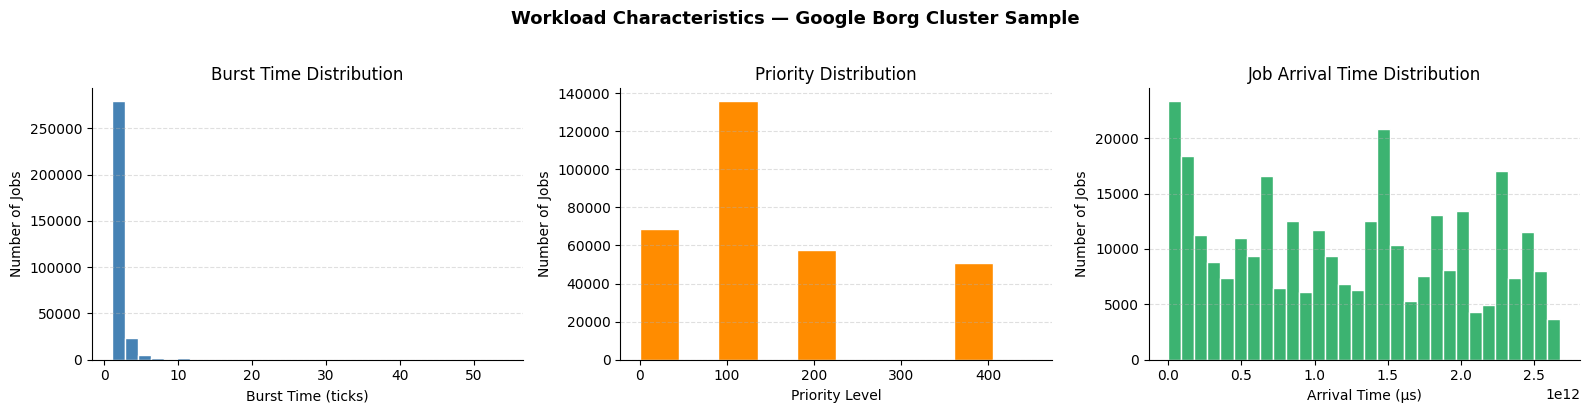

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['Burst_Time'],    bins=30, color='steelblue',     edgecolor='white')
axes[0].set_title('Burst Time Distribution')
axes[0].set_xlabel('Burst Time (ticks)')
axes[0].set_ylabel('Number of Jobs')

axes[1].hist(df['Priority'],      bins=10, color='darkorange',    edgecolor='white')
axes[1].set_title('Priority Distribution')
axes[1].set_xlabel('Priority Level')
axes[1].set_ylabel('Number of Jobs')

axes[2].hist(df['Arrival_Time'],  bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Job Arrival Time Distribution')
axes[2].set_xlabel('Arrival Time (\u03bcs)')
axes[2].set_ylabel('Number of Jobs')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Workload Characteristics — Google Borg Cluster Sample',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Feature Engineering — Synthetic Deadlines

Several scheduling algorithms (notably EDF) require explicit job deadlines. Since the Borg traces do not include deadline fields, we synthesise them as:

$$\text{Deadline}_i = \text{Arrival\_Time}_i + \text{Burst\_Time}_i + \epsilon_i, \quad \epsilon_i \sim \mathcal{U}(20,\, 200)$$

This models a realistic soft-deadline scenario where each job has some slack beyond its minimum execution requirement.

In [11]:
np.random.seed(42)
deadline_slack = np.random.randint(20, 200, size=len(df))
df['Deadline'] = df['Arrival_Time'] + df['Burst_Time'] + deadline_slack

# Finalise the scheduler input dataframe
scheduler_df = df[['PID', 'Arrival_Time', 'Burst_Time', 'Priority', 'Deadline']].copy()

print(f"Scheduler dataframe shape: {scheduler_df.shape}")
scheduler_df.head()

Scheduler dataframe shape: (313216, 5)


,PID,Arrival_Time,Burst_Time,Priority,Deadline
0,376,81300000000,3,103,81300000125
1,3907,1565315000000,1,0,1565315000200
2,345,1626600000000,8,103,1626600000120
3,13138,343800000000,1,117,343800000035
4,393,455400000000,1,103,455400000127


---

## 5. Simulation Setup

To make the simulation tractable and to create genuine CPU contention, we apply the following transformations before running the schedulers:

| Step | Operation | Rationale |
|------|-----------|-----------|
| 1 | Sample 500 jobs (`random_state=42`) | Reproducibility; fast iteration |
| 2 | Sort by `Arrival_Time` | Ensures correct simulation order |
| 3 | Normalise arrivals to $t_0 = 0$ | Removes absolute timestamp offset |
| 4 | Compress inter-arrival gaps (`÷ 10,000,000`) | Creates CPU contention — jobs overlap |
| 5 | Inflate burst times (`× 10,000`) | Makes job durations non-trivial relative to arrivals |

We then report **scheduling overlaps** — how many jobs arrive while another job is still running — to confirm the workload creates meaningful scheduling decisions.

In [12]:
# Reproducible 500-job sample, sorted by arrival
df = scheduler_df.drop(columns=['PID']).sample(500, random_state=42)
df = df.sort_values("Arrival_Time").reset_index(drop=True)

# Normalise so the first job arrives at t = 0
df['Arrival_Time'] = df['Arrival_Time'] - df['Arrival_Time'].min()

# Compress inter-arrival gaps; inflate burst times to create CPU contention
df['Arrival_Time'] = df['Arrival_Time'] // 10_000_000
df['Burst_Time']   = df['Burst_Time']   *  10_000

# Recalculate deadlines on the rescaled timeline
np.random.seed(42)
df['Deadline'] = df['Arrival_Time'] + df['Burst_Time'] + np.random.randint(20, 200, size=len(df))

# Verify scheduling overlaps
overlaps = sum(
    df.loc[i, 'Arrival_Time'] < df.loc[i-1, 'Arrival_Time'] + df.loc[i-1, 'Burst_Time']
    for i in range(1, len(df))
)

print(f"Total jobs            : {len(df)}")
print(f"Arrival Time range    : {df['Arrival_Time'].min()}  →  {df['Arrival_Time'].max()}")
print(f"Burst Time range      : {df['Burst_Time'].min()}  →  {df['Burst_Time'].max()}")
print(f"Scheduling overlaps   : {overlaps}  ({overlaps / len(df) * 100:.1f}% of jobs)")
df.head()

Total jobs            : 500
Arrival Time range    : 0  →  265980
Burst Time range      : 10000  →  500000
Scheduling overlaps   : 499  (99.8% of jobs)


,Arrival_Time,Burst_Time,Priority,Deadline
0,0,10000,0,10122
1,1560,40000,200,41759
2,1950,10000,360,12062
3,1950,10000,360,11984
4,1950,10000,360,12076


---

## 6. CPU Scheduling Algorithm Implementations

Each scheduler is implemented as a standalone Python function that accepts the job dataframe and returns a metrics dictionary. All schedulers share a common set of helper functions.

### 6.1 Metric Helper Functions

Two utility functions are shared by all schedulers:

- **`fairness_index(waiting_times)`** — Jain's Fairness Index. Ranges from 0 (maximally unfair) to 1 (all jobs wait equally). Defined as:
$$J = \frac{\left(\sum_i x_i\right)^2}{n \cdot \sum_i x_i^2}$$

- **`compute_metrics(processes, context_switches)`** — Aggregates per-job completion records into the five reported performance metrics.

In [13]:
def fairness_index(waiting_times):
    """
    Jain's Fairness Index.
    Returns a value in (0, 1]: 1.0 = perfectly equal waiting times.
    """
    x = np.array(waiting_times, dtype=float)
    return (np.sum(x) ** 2) / (len(x) * np.sum(x ** 2) + 1e-9)


def compute_metrics(processes, context_switches):
    """
    Aggregate scheduling metrics from a completed simulation run.

    Parameters
    ----------
    processes : list[dict]
        Each dict must contain keys 'arrival', 'start', 'finish', 'burst'.
    context_switches : int
        Total context switches performed by the scheduler.

    Returns
    -------
    dict
        avg_waiting, avg_turnaround, avg_response, throughput, context_switches, fairness.
    """
    if not processes:
        return {"avg_waiting": 0, "avg_turnaround": 0, "avg_response": 0,
                "throughput": 0, "context_switches": 0, "fairness": 0}

    wait_times       = [p['finish'] - p['arrival'] - p['burst'] for p in processes]
    turnaround_times = [p['finish'] - p['arrival']              for p in processes]
    response_times   = [p['start']  - p['arrival']              for p in processes]

    total_time = max(p['finish'] for p in processes) - min(p['arrival'] for p in processes)
    throughput = len(processes) / total_time if total_time > 0 else 0

    return {
        "avg_waiting":      np.mean(wait_times),
        "avg_turnaround":   np.mean(turnaround_times),
        "avg_response":     np.mean(response_times),
        "throughput":       throughput,
        "context_switches": context_switches,
        "fairness":         fairness_index(wait_times),
    }

### 6.2 First Come First Served (FCFS)

The simplest non-preemptive algorithm. Jobs are executed strictly in order of arrival. The CPU fast-forwards to the next arrival if it becomes idle.

- **Preemptive:** No  
- **Complexity:** O(n log n) sort + O(n) simulation  
- **Known weakness:** Convoy effect — long jobs delay all subsequent shorter jobs.

In [14]:
def fcfs(df):
    """First Come First Served (non-preemptive)."""
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    time, processes = 0, []

    for job in jobs:
        if time < job['Arrival_Time']:
            time = job['Arrival_Time']   # CPU idle; fast-forward to next arrival
        time += job['Burst_Time']
        processes.append({
            'arrival': job['Arrival_Time'],
            'start':   time - job['Burst_Time'],
            'finish':  time,
            'burst':   job['Burst_Time'],
        })

    return compute_metrics(processes, context_switches=0)

### 6.3 Shortest Job First (SJF)

Non-preemptive. Among all jobs that have arrived by time *t*, the one with the smallest burst time is selected. A min-heap provides O(log n) selection.

- **Preemptive:** No (preemptive variant is SRTN — not implemented here)  
- **Complexity:** O(n log n)  
- **Known weakness:** Requires advance knowledge of burst times (oracle assumption); may starve long jobs.

In [15]:
def sjf(df):
    """Shortest Job First (non-preemptive)."""
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, job_id = len(jobs), 0, 0, 0
    queue, processes = [], []

    while i < n or queue:
        # Enqueue all jobs that have arrived
        while i < n and jobs[i]['Arrival_Time'] <= time:
            heapq.heappush(queue, (jobs[i]['Burst_Time'], job_id, jobs[i]))
            job_id += 1
            i += 1

        if not queue:
            time = jobs[i]['Arrival_Time']   # CPU idle
            continue

        burst, _, job = heapq.heappop(queue)
        time += burst
        processes.append({
            'arrival': job['Arrival_Time'],
            'start':   time - job['Burst_Time'],
            'finish':  time,
            'burst':   job['Burst_Time'],
        })

    return compute_metrics(processes, context_switches=n)

### 6.4 Round Robin (RR)

Preemptive. Each job receives a fixed time slice (*quantum* = 10). If not finished, the job is re-queued. New arrivals during a time slice are added before the preempted job is re-queued, giving priority to fresh arrivals.

- **Preemptive:** Yes  
- **Time quantum:** 10 time units  
- **Strength:** Bounded response time; widely used in interactive and time-sharing systems.

In [16]:
def round_robin(df, quantum=10):
    """Round Robin (preemptive, fixed time quantum)."""
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, context = len(jobs), 0, 0, 0
    queue, remaining, first_run, processes = deque(), {}, {}, []

    while i < n or queue:
        while i < n and jobs[i]['Arrival_Time'] <= time:
            remaining[i] = jobs[i]['Burst_Time']
            queue.append(i)
            i += 1

        if not queue:
            time = jobs[i]['Arrival_Time']
            continue

        pid       = queue.popleft()
        if pid not in first_run:
            first_run[pid] = time   # record first CPU allocation
        exec_time = min(quantum, remaining[pid])
        time     += exec_time
        remaining[pid] -= exec_time
        context  += 1

        # Enqueue new arrivals that became ready during this time slice
        while i < n and jobs[i]['Arrival_Time'] <= time:
            remaining[i] = jobs[i]['Burst_Time']
            queue.append(i)
            i += 1

        if remaining[pid] == 0:
            processes.append({
                'arrival': jobs[pid]['Arrival_Time'],
                'start':   first_run[pid],
                'finish':  time,
                'burst':   jobs[pid]['Burst_Time'],
            })
        else:
            queue.append(pid)   # Re-queue for next time slice

    return compute_metrics(processes, context_switches=context)

### 6.5 Priority Scheduling

Non-preemptive. Among all ready jobs, the one with the **lowest priority value** (highest urgency, following Borg's convention where lower numbers = higher priority) is selected next.

- **Preemptive:** No  
- **Complexity:** O(n log n)  
- **Known weakness:** Low-priority jobs may starve if high-priority jobs keep arriving (priority inversion risk).

In [17]:
def priority_sched(df):
    """Non-preemptive Priority Scheduling (lower value = higher priority)."""
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, job_id, context = len(jobs), 0, 0, 0, 0
    queue, processes = [], []

    while i < n or queue:
        while i < n and jobs[i]['Arrival_Time'] <= time:
            heapq.heappush(queue, (jobs[i]['Priority'], job_id, jobs[i]))
            job_id += 1
            i += 1

        if not queue:
            time = jobs[i]['Arrival_Time']
            continue

        _, _, job = heapq.heappop(queue)
        time    += job['Burst_Time']
        context += 1
        processes.append({
            'arrival': job['Arrival_Time'],
            'start':   time - job['Burst_Time'],
            'finish':  time,
            'burst':   job['Burst_Time'],
        })

    return compute_metrics(processes, context_switches=context)

### 6.6 Multilevel Queue (MLQ)

Jobs are permanently assigned to one of two fixed queues based on priority:

| Queue | Condition | Policy |
|-------|-----------|--------|
| High (`q_high`) | `Priority < 100` | Round Robin (quantum = 10) |
| Low (`q_low`) | `Priority ≥ 100` | FCFS, preempted by high-priority arrivals |

The high-priority queue is always served first. Low-priority jobs only run when `q_high` is empty.

- **Preemptive:** Partially — within-queue preemption via RR for high queue; between-queue preemption is implicit (low queue is blocked while high queue is non-empty).

In [18]:
def multilevel_queue(df, quantum=10):
    """
    Multilevel Queue Scheduler.
    High-priority jobs (Priority < 100)  : Round Robin with given quantum.
    Low-priority  jobs (Priority >= 100) : FCFS, preempted by high-priority arrivals.
    """
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, context = len(jobs), 0, 0, 0
    q_high, q_low, remaining, first_run, processes = deque(), deque(), {}, {}, []

    while i < n or q_high or q_low:
        while i < n and jobs[i]['Arrival_Time'] <= time:
            remaining[i] = jobs[i]['Burst_Time']
            if jobs[i].get('Priority', 100) < 100:
                q_high.append(i)
            else:
                q_low.append(i)
            i += 1

        if not q_high and not q_low:
            time = jobs[i]['Arrival_Time']
            continue

        if q_high:
            pid       = q_high.popleft()
            if pid not in first_run:
                first_run[pid] = time
            exec_time = min(quantum, remaining[pid])
            time     += exec_time
            remaining[pid] -= exec_time
            context  += 1

            while i < n and jobs[i]['Arrival_Time'] <= time:
                remaining[i] = jobs[i]['Burst_Time']
                if jobs[i].get('Priority', 100) < 100:
                    q_high.append(i)
                else:
                    q_low.append(i)
                i += 1

            if remaining[pid] == 0:
                processes.append({'arrival': jobs[pid]['Arrival_Time'], 'start': first_run[pid], 'finish': time, 'burst': jobs[pid]['Burst_Time']})
            else:
                q_high.append(pid)
        else:
            pid          = q_low.popleft()
            if pid not in first_run:
                first_run[pid] = time
            time_to_next = jobs[i]['Arrival_Time'] - time if i < n else float('inf')
            run_time     = min(remaining[pid], time_to_next)
            time        += run_time
            remaining[pid] -= run_time
            context     += 1

            if remaining[pid] == 0:
                processes.append({'arrival': jobs[pid]['Arrival_Time'], 'start': first_run[pid], 'finish': time, 'burst': jobs[pid]['Burst_Time']})
            else:
                q_low.appendleft(pid)   # Preempted; re-insert at front

    return compute_metrics(processes, context_switches=context)

### 6.7 Multi-Level Feedback Queue (MLFQ)

Jobs enter at the highest-priority queue (Q1) and are dynamically demoted after exhausting their quantum, modelling the distinction between I/O-bound (short, stay in Q1) and CPU-bound (long, sink to Q3) processes.

| Queue | Quantum | On Exhaustion |
|-------|---------|---------------|
| Q1 (highest priority) | 8  | Demote to Q2 |
| Q2 | 16 | Demote to Q3 |
| Q3 (lowest priority) | ∞ (FCFS) | Stays in Q3; preempted by Q1/Q2 arrivals |

- **Preemptive:** Yes — new Q1 arrivals preempt Q2/Q3 jobs  
- **Strength:** Automatically adapts to job behaviour without prior knowledge of burst times.

In [19]:
def mlfq(df):
    """
    Multi-Level Feedback Queue.
    Q1 quantum = 8,  Q2 quantum = 16,  Q3 = FCFS.
    Jobs are demoted after exhausting their queue's quantum.
    """
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, context = len(jobs), 0, 0, 0
    q1, q2, q3 = deque(), deque(), deque()
    remaining, first_run, processes = {}, {}, []

    while i < n or q1 or q2 or q3:
        while i < n and jobs[i]['Arrival_Time'] <= time:
            remaining[i] = jobs[i]['Burst_Time']
            q1.append(i)   # All new arrivals enter Q1
            i += 1

        if not (q1 or q2 or q3):
            time = jobs[i]['Arrival_Time']
            continue

        if q1:
            pid       = q1.popleft()
            if pid not in first_run:
                first_run[pid] = time
            exec_time = min(8, remaining[pid])
            time     += exec_time
            remaining[pid] -= exec_time
            context  += 1

            while i < n and jobs[i]['Arrival_Time'] <= time:
                remaining[i] = jobs[i]['Burst_Time']
                q1.append(i)
                i += 1

            if remaining[pid] == 0:
                processes.append({'arrival': jobs[pid]['Arrival_Time'], 'start': first_run[pid], 'finish': time, 'burst': jobs[pid]['Burst_Time']})
            else:
                q2.append(pid)   # Demote to Q2

        elif q2:
            pid          = q2.popleft()
            if pid not in first_run:
                first_run[pid] = time
            time_to_next = jobs[i]['Arrival_Time'] - time if i < n else float('inf')
            exec_time    = min(16, remaining[pid], time_to_next)
            time        += exec_time
            remaining[pid] -= exec_time
            context     += 1

            if remaining[pid] == 0:
                processes.append({'arrival': jobs[pid]['Arrival_Time'], 'start': first_run[pid], 'finish': time, 'burst': jobs[pid]['Burst_Time']})
            elif exec_time == 16:
                q3.append(pid)         # Demote to Q3
            else:
                q2.appendleft(pid)     # Preempted by arrival; stays in Q2

        else:   # Q3 — FCFS
            pid          = q3.popleft()
            if pid not in first_run:
                first_run[pid] = time
            time_to_next = jobs[i]['Arrival_Time'] - time if i < n else float('inf')
            exec_time    = min(remaining[pid], time_to_next)
            time        += exec_time
            remaining[pid] -= exec_time
            context     += 1

            if remaining[pid] == 0:
                processes.append({'arrival': jobs[pid]['Arrival_Time'], 'start': first_run[pid], 'finish': time, 'burst': jobs[pid]['Burst_Time']})
            else:
                q3.appendleft(pid)

    return compute_metrics(processes, context_switches=context)

### 6.8 Earliest Deadline First (EDF)

Preemptive. At every scheduling event, the job with the **nearest absolute deadline** is selected. A new arrival with a tighter deadline immediately preempts the running job.

- **Preemptive:** Yes  
- **Complexity:** O(log n) per scheduling event (heap)  
- **Optimality:** EDF is optimal for uniprocessor real-time scheduling — if any feasible schedule exists, EDF will find one  
- **Known weakness:** Catastrophic deadline-miss cascades under CPU overload.

In [20]:
def edf(df):
    """
    Earliest Deadline First (preemptive).
    Heap entry format: (deadline, job_id, remaining_burst, arrival_time, total_burst).
    """
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, job_id, context = len(jobs), 0, 0, 0, 0
    queue, processes, current_job, first_run = [], [], None, {}

    while i < n or queue or current_job:
        while i < n and jobs[i]['Arrival_Time'] <= time:
            deadline = jobs[i].get('Deadline', jobs[i]['Arrival_Time'] + 1000)
            heapq.heappush(queue, (
                deadline, job_id,
                jobs[i]['Burst_Time'],    # remaining burst
                jobs[i]['Arrival_Time'],  # arrival
                jobs[i]['Burst_Time'],    # total burst (for metrics)
            ))
            job_id += 1
            i += 1

        # Preempt current job if a tighter-deadline job has arrived
        if current_job:
            if queue and queue[0][0] < current_job[0]:
                heapq.heappush(queue, current_job)
                current_job = heapq.heappop(queue)
                context += 1
                if current_job[1] not in first_run:
                    first_run[current_job[1]] = time
        else:
            if queue:
                current_job = heapq.heappop(queue)
                context += 1
                if current_job[1] not in first_run:
                    first_run[current_job[1]] = time

        if current_job:
            time_to_finish = current_job[2]
            time_to_next   = jobs[i]['Arrival_Time'] - time if i < n else float('inf')
            run_time       = min(time_to_finish, time_to_next)

            time        += run_time
            current_job  = (
                current_job[0], current_job[1],
                current_job[2] - run_time,   # update remaining burst
                current_job[3], current_job[4],
            )
            if current_job[2] == 0:
                processes.append({'arrival': current_job[3], 'start': first_run[current_job[1]], 'finish': time, 'burst': current_job[4]})
                current_job = None
        else:
            if i < n:
                time = jobs[i]['Arrival_Time']

    return compute_metrics(processes, context_switches=context)

### 6.9 Completely Fair Scheduler (CFS)

Linux's production scheduler since kernel 2.6.23. Instead of fixed time slices, CFS tracks **virtual runtime (vruntime)** — the normalised CPU time each job has consumed. The job with the **lowest vruntime** is always scheduled next, ensuring proportional CPU allocation.

- **Preemptive:** Yes — new arrivals (vruntime = 0) immediately preempt higher-vruntime jobs  
- **Time slice:** `base_slice` = 10 time units  
- **Complexity:** O(log n) per event via a min-heap on vruntime  
- **Strength:** Excellent fairness with low overhead; handles mixed workloads gracefully.

In [21]:
def cfs(df, base_slice=10):
    """
    Completely Fair Scheduler.
    Selects the job with the lowest virtual runtime (vruntime) at each scheduling point.
    Heap entry format: (vruntime, job_id, arrival_time, remaining_burst, total_burst).
    """
    jobs = df.sort_values("Arrival_Time").to_dict('records')
    n, time, i, job_id, context = len(jobs), 0, 0, 0, 0
    queue, processes, current_job, first_run = [], [], None, {}

    while i < n or queue or current_job:
        min_vruntime = queue[0][0] if queue else (current_job[0] if current_job else 0)
        while i < n and jobs[i]['Arrival_Time'] <= time:
            heapq.heappush(queue, (
                min_vruntime, job_id,                 # new arrivals start at min_vruntime
                jobs[i]['Arrival_Time'],
                jobs[i]['Burst_Time'],     # remaining burst
                jobs[i]['Burst_Time'],     # total burst
            ))
            job_id += 1
            i += 1

        # Preempt if a lower-vruntime job arrived
        if current_job:
            if queue and queue[0][0] < current_job[0]:
                heapq.heappush(queue, current_job)
                current_job = heapq.heappop(queue)
                context += 1
                if current_job[1] not in first_run:
                    first_run[current_job[1]] = time
        else:
            if queue:
                current_job = heapq.heappop(queue)
                context += 1
                if current_job[1] not in first_run:
                    first_run[current_job[1]] = time

        if current_job:
            vruntime, pid, arrival, rem_burst, tot_burst = current_job
            time_to_next = jobs[i]['Arrival_Time'] - time if i < n else float('inf')
            run_time     = min(base_slice, rem_burst, time_to_next)

            time      += run_time
            rem_burst -= run_time
            vruntime  += run_time   # vruntime increases by actual CPU time used

            if rem_burst == 0:
                processes.append({'arrival': arrival, 'start': first_run[pid], 'finish': time, 'burst': tot_burst})
                current_job = None
            else:
                current_job = (vruntime, pid, arrival, rem_burst, tot_burst)
                if run_time >= base_slice or run_time == time_to_next:
                    heapq.heappush(queue, current_job)   # Re-queue with updated vruntime
                    current_job = None
                    context += 1
        else:
            if i < n:
                time = jobs[i]['Arrival_Time']

    return compute_metrics(processes, context_switches=context)

---

## 7. Results & Comparison

All eight schedulers are executed on the same 500-job workload sample. Results are aggregated into a summary table for direct side-by-side comparison.

In [22]:
results = {
    "FCFS":        fcfs(df),
    "SJF":         sjf(df),
    "Round Robin": round_robin(df),
    "Priority":    priority_sched(df),
    "MLQ":         multilevel_queue(df),
    "MLFQ":        mlfq(df),
    "EDF":         edf(df),
    "CFS":         cfs(df),
}

results_df = pd.DataFrame(results).T
results_df.index.name = "Algorithm"

# Formatted display table
display_df = results_df.copy()
display_df[["avg_waiting", "avg_turnaround", "avg_response"]] = display_df[["avg_waiting", "avg_turnaround", "avg_response"]].round(2)
display_df["throughput"]       = display_df["throughput"].map("{:.6f}".format)
display_df["fairness"]         = display_df["fairness"].map("{:.4f}".format)
display_df["context_switches"] = display_df["context_switches"].astype(int)
display_df.columns = [
    "Avg Waiting Time", "Avg Turnaround Time", "Avg Response Time",
    "Throughput (jobs/t)", "Context Switches", "Fairness Index"
]

print("=== Scheduling Algorithm Performance Summary ===")
display_df

=== Scheduling Algorithm Performance Summary ===


,Avg Waiting Time,Avg Turnaround Time,Avg Response Time,Throughput (jobs/t),Context Switches,Fairness Index
Algorithm,,,,,,
FCFS,3839612.22,3855592.22,3839612.22,0.000063,0,0.7435
SJF,2492492.22,2508472.22,2492492.22,0.000063,500,0.7068
Round Robin,5018772.46,5034752.46,2486.54,0.000063,799000,0.9866
Priority,3366712.22,3382692.22,3366712.22,0.000063,500,0.6682
MLQ,3654985.08,3670965.08,3489270.92,0.000063,112397,0.7281
MLFQ,3845444.42,3861424.42,13.48,0.000063,1768,0.7446
EDF,3226472.22,3242452.22,3226472.22,0.000063,500,0.7127
CFS,5101345.38,5117325.38,16.83,0.000063,1597748,0.9886


---

## 8. Performance Visualization

The plots below compare all eight algorithms across each metric.

- **Lower is better:** Average Waiting Time, Average Turnaround Time, Context Switches  
- **Higher is better:** Throughput, Fairness Index

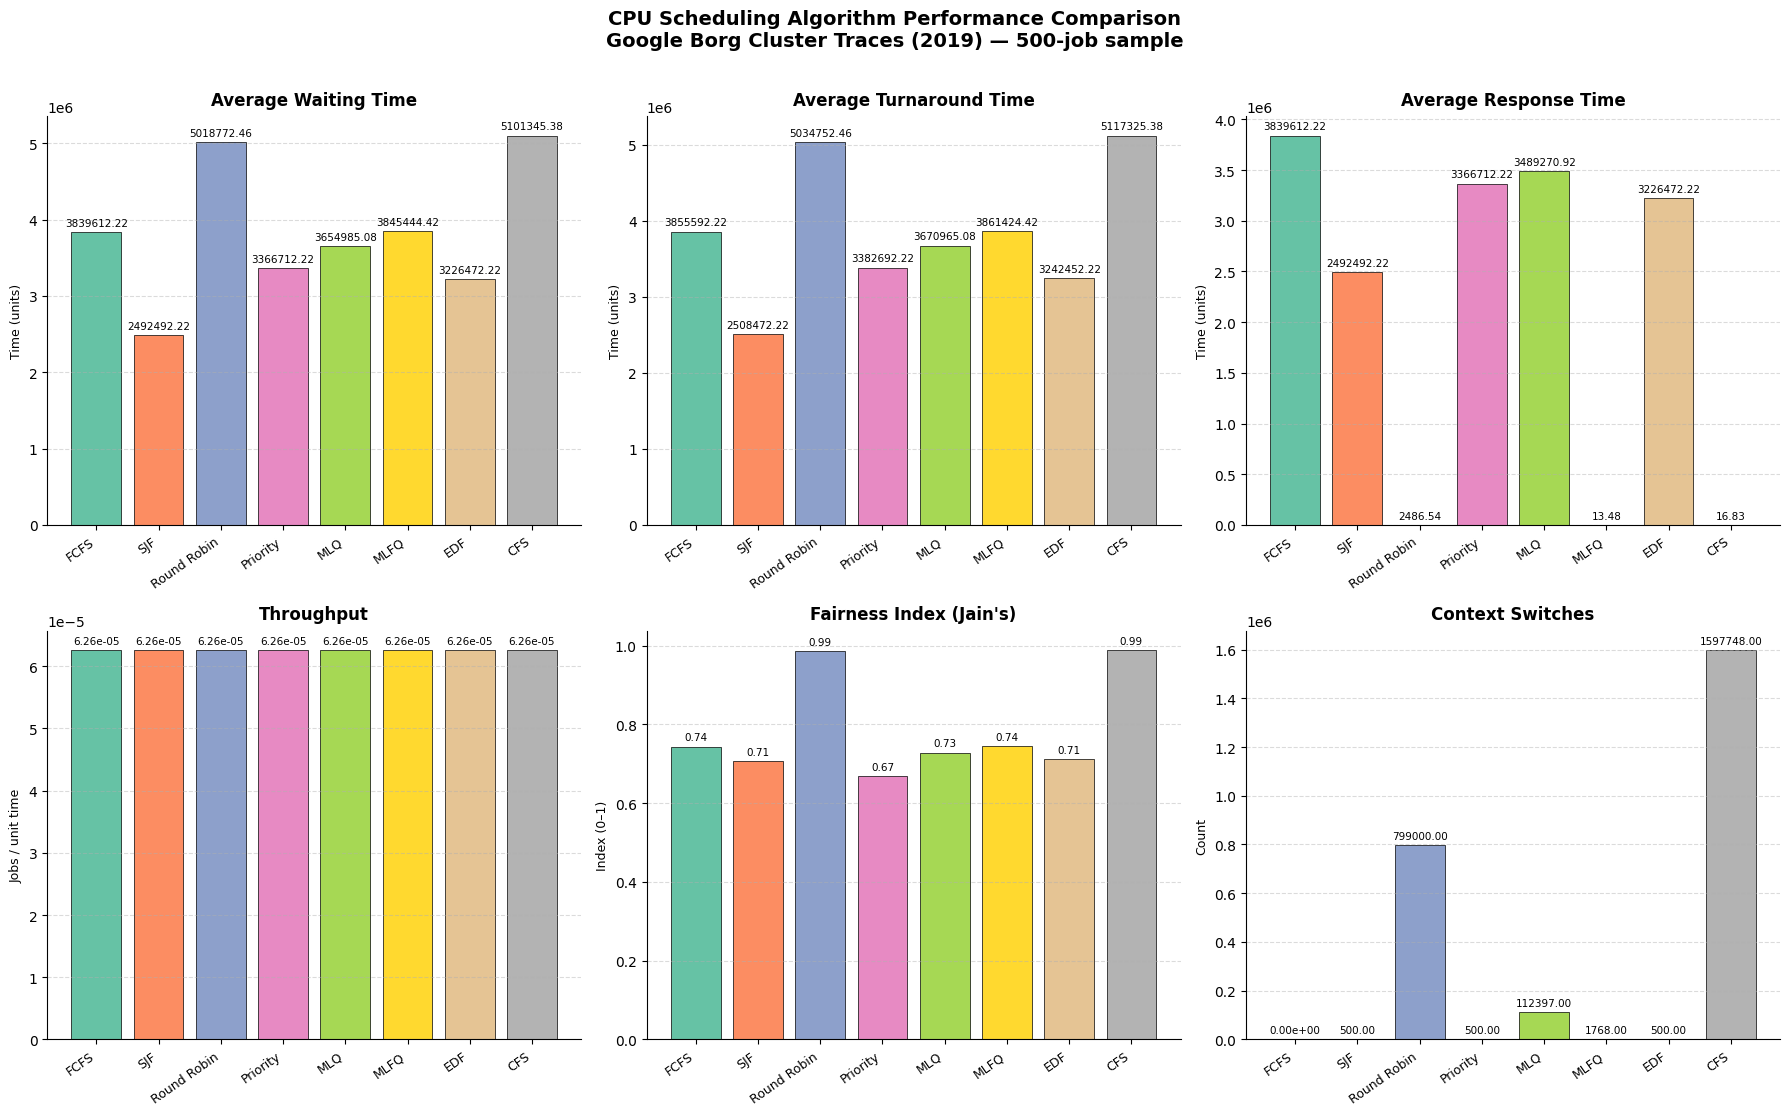

Figure saved as 'scheduling_comparison.png'


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

metrics = [
    ("avg_waiting",      "Average Waiting Time",       "Time (units)"),
    ("avg_turnaround",   "Average Turnaround Time",    "Time (units)"),
    ("avg_response",     "Average Response Time",      "Time (units)"),
    ("throughput",       "Throughput",                 "Jobs / unit time"),
    ("fairness",         "Fairness Index (Jain's)",    "Index (0\u20131)"),
    ("context_switches", "Context Switches",           "Count"),
]

palette = list(plt.cm.Set2.colors)

for idx, (metric, title, ylabel) in enumerate(metrics):
    ax     = axes[idx]
    values = results_df[metric].astype(float)
    bars   = ax.bar(
        results_df.index, values,
        color=palette[:len(results_df)],
        edgecolor='black', linewidth=0.5,
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    
    # FIX: Explicitly set tick positions before setting tick labels
    ax.set_xticks(range(len(results_df.index)))
    ax.set_xticklabels(results_df.index, rotation=35, ha='right', fontsize=9)
    
    ax.grid(axis='y', linestyle='--', alpha=0.45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar in bars:
        h     = bar.get_height()
        label = f"{h:.2e}" if h < 0.001 else f"{h:.2f}"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', fontsize=7.5,
        )

fig.suptitle(
    "CPU Scheduling Algorithm Performance Comparison\n"
    "Google Borg Cluster Traces (2019) \u2014 500-job sample",
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig("scheduling_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'scheduling_comparison.png'")